## Machine Learning with KNN MODEL

In [2]:
! pip install -qU transformers sklearn seaborn matplotlib pandas

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [4]:
# import necessary libraries

import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt 
import seaborn as sns

## Load the data

In [5]:
data = pd.read_csv("titanic.csv")
data.info()
print(data.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Data Preprocessing

In [6]:
# Data Cleaning and Feature Engineering 
def preprocess_data(df):
    df.drop(columns=["PassengerId", "Name", "Ticket","Cabin"], inplace=True)
    
    df["Embarked"].fillna("S", inplace=True)
    df.drop(columns=["Embarked"], inplace=True)
    
    fill_missing_ages(df)
    
    # Convert Gender
    df["Sex"] = df["Sex"].map({'male':1,"female":0})
    
    # Feature Enginnering 
    df["FamilySize"] = df["SibSp"] + df["Parch"]
    df["IsAlone"] = np.where(df["FamilySize"] == 0, 1, 0)
    df["FareBin"] = pd.qcut(df["Fare"], 4, labels=False)
    df["AgeBin"] = pd.cut(df["Age"], bins=[0,12,20,40,60, np.inf],labels=False)
    
    return df

In [8]:
# Fill in missing ages
def fill_missing_ages(df):
    age_fill_map = {}
    for pclass in df["Pclass"].unique():
        if pclass not in age_fill_map:
            age_fill_map[pclass] = df[df["Pclass"] == pclass]["Age"].median()
            
    df["Age"] = df.apply(lambda row: age_fill_map[row["Pclass"]] if pd.isnull(row["Age"]) else row["Age"], axis=1)

data = preprocess_data(data)   

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   FamilySize  891 non-null    int64  
 8   IsAlone     891 non-null    int64  
 9   FareBin     891 non-null    int64  
 10  AgeBin      891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


C:\Users\user2\AppData\Local\Temp\ipykernel_3392\2096457081.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Embarked"].fillna("S", inplace=True)


## Split Data for ML preparation

In [9]:
# Create Features / Target Variables (Make Flashcards)
X = data.drop(columns=["Survived"])
y = data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [10]:
# ML Preprocessing 
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## USE KNN Model for Prediction

In [11]:
# Hyperparemeter Tuning - KNN 
def tune_model(X_train, y_train):
    param_grid = {
        "n_neighbors":range(1,21),
        "metric" : ["euclidean", "manhattan", "minkowski"],
        "weights" : ["uniform","distance"]
    }
    
    model = KNeighborsClassifier()
    grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_


best_model = tune_model(X_train, y_train)

## Predict and Evaluate

In [12]:
# Predictions and evaulate
def evaluate_model(model, X_test, y_test):
    prediction = model.predict(X_test)
    accuracy = accuracy_score(y_test, prediction)
    matrix = confusion_matrix(y_test, prediction)
    return accuracy, matrix

accuracy, matrix = evaluate_model(best_model, X_test, y_test)

print(f'Accuracy: {accuracy*100:.2f}%')
print(f'Confusion Matrix:')
print(matrix)


Accuracy: 80.27%
Confusion Matrix:
[[115  19]
 [ 25  64]]


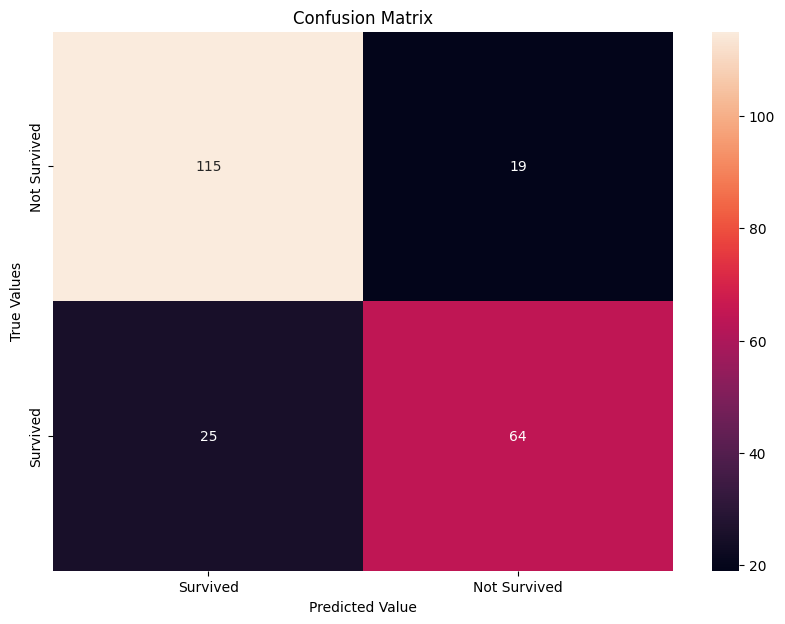

In [13]:
# Plot
def plot_model(matrix):
    plt.figure(figsize=(10,7))
    sns.heatmap(matrix, annot=True, fmt="d", xticklabels=["Survived","Not Survived"], yticklabels=["Not Survived", "Survived"])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Value")
    plt.ylabel("True Values")
    plt.show()
    
    
plot_model(matrix)   